In [ ]:
import sys
sys.path.insert(0, '../')
import pandas as pd
from helpers_finalizacion_carrera import plot_tiempo_cursando

# Dejando fijo el intervalo de tiempo

## Fisica

In [2]:
egresados_fisica_2020_2025 = pd.DataFrame()
for anio in range(2020, 2026):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/fisica/resumen_egresados_fisica_{anio}.csv')
    egresados_fisica_2020_2025 = pd.concat([egresados_fisica_2020_2025, egresados])

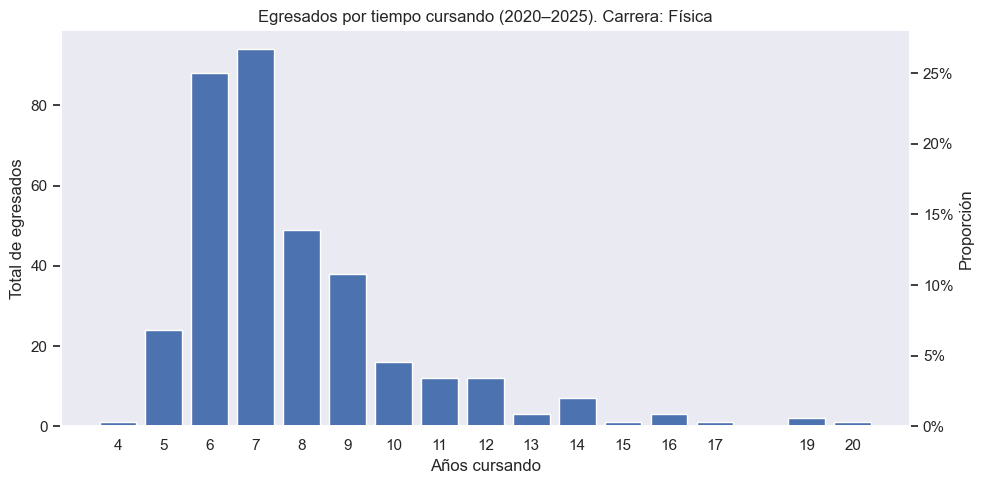

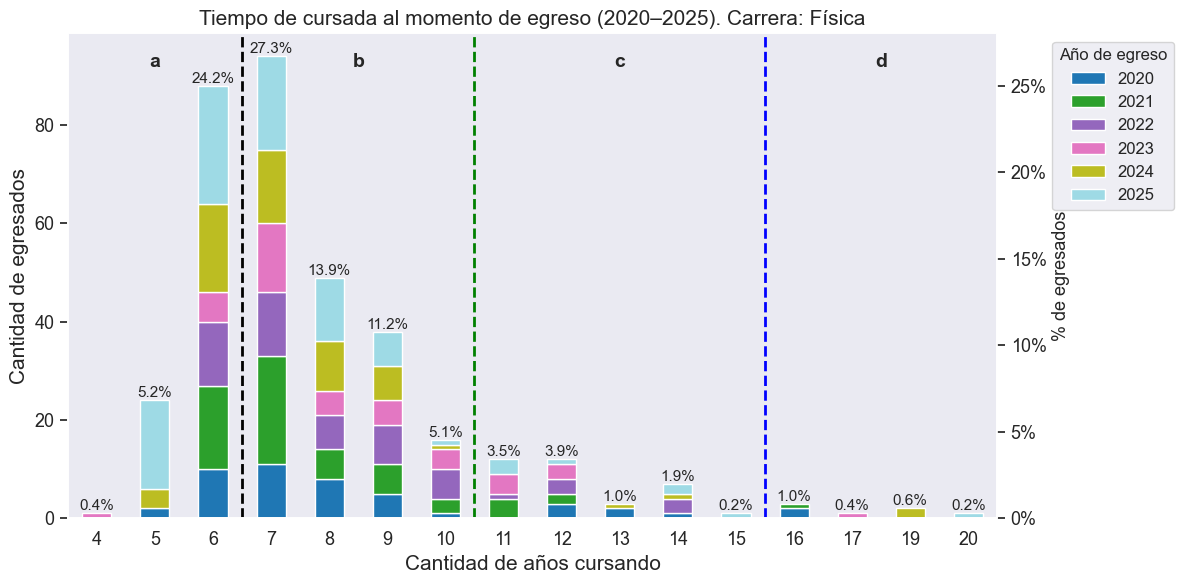

 tiempo_cursando  total_egreso
               4             1
               5            24
               6            88
               7            94
               8            49
               9            38
              10            16
              11            12
              12            12
              13             3
              14             7
              15             1
              16             3
              17             1
              19             2
              20             1
anio_egreso      2020  2021  2022  2023  2024  2025
tiempo_cursando                                    
4                   0     0     0     1     0     0
5                   2     0     0     0     4    18
6                  10    17    13     6    18    24
7                  11    22    13    14    15    19
8                   8     6     7     5    10    13
9                   5     6     8     5     7     7
10                  1     3     6     4     1     1
11   

In [3]:
total_por_tiempo_2020_2025, resumen_por_cohorte_2020_2025, promedio_ponderado = plot_tiempo_cursando(egresados_fisica_2020_2025, 'Física', anio_desde=2020, anio_hasta=2025, mostrar_rectas_verticales=True)

In [4]:
resumen_por_cohorte_2020_2025

anio_egreso,2020,2021,2022,2023,2024,2025
tiempo_cursando,,,,,,
4,0,0,0,1,0,0
5,2,0,0,0,4,18
6,10,17,13,6,18,24
7,11,22,13,14,15,19
8,8,6,7,5,10,13
9,5,6,8,5,7,7
10,1,3,6,4,1,1
11,0,4,1,4,0,3
12,3,2,3,3,0,1


In [5]:
resumen_por_cohorte_2020_2025.sum()

anio_egreso
2020    45
2021    61
2022    54
2023    43
2024    59
2025    90
dtype: int64

Calculo a, b, c y "d" usando las proporciones reales, no las ponderadas.

In [57]:
# sumo tiempo cursando de 4 a 6 y lo divido por el total de egresados para obtener la proporción de egresados que se demoraron entre 4 y 6 años en finalizar la carrera
a = total_por_tiempo_2020_2025[total_por_tiempo_2020_2025['tiempo_cursando'] <= 6]['total_egreso'].sum() / total_por_tiempo_2020_2025['total_egreso'].sum()
b = total_por_tiempo_2020_2025[(total_por_tiempo_2020_2025['tiempo_cursando'] > 6) & (total_por_tiempo_2020_2025['tiempo_cursando'] <= 10)]['total_egreso'].sum() / total_por_tiempo_2020_2025['total_egreso'].sum()
c = total_por_tiempo_2020_2025[(total_por_tiempo_2020_2025['tiempo_cursando'] > 10) & (total_por_tiempo_2020_2025['tiempo_cursando'] <= 15)]['total_egreso'].sum() / total_por_tiempo_2020_2025['total_egreso'].sum()
d = total_por_tiempo_2020_2025[total_por_tiempo_2020_2025['tiempo_cursando'] > 15]['total_egreso'].sum() / total_por_tiempo_2020_2025['total_egreso'].sum()

In [59]:
print(f"a =", a)
print(f"b =", b)
print(f"c =", c)
print(f"d =", d)

a = 0.3210227272727273
b = 0.5596590909090909
c = 0.09943181818181818
d = 0.019886363636363636


Primero estimamos P(10 < X-X_0 <= 15), es decir la probabilidad de que tarde entre 11 y 15 años en recibirse.

In [6]:
# Proporción por año con tiempo_cursando entre 11 y 15 (inclusive)
mask_11_15 = resumen_por_cohorte_2020_2025.index.to_series().between(11, 15)
proporcion_11_15_por_anio = (
    resumen_por_cohorte_2020_2025.loc[mask_11_15].sum()
    / resumen_por_cohorte_2020_2025.sum()
)
proporcion_11_15_por_anio = proporcion_11_15_por_anio.rename('proporcion_15_20')

proporcion_11_15_por_anio

anio_egreso
2020    0.133333
2021    0.098361
2022    0.129630
2023    0.162791
2024    0.033898
2025    0.077778
Name: proporcion_15_20, dtype: float64

Calculamos el desvio estandar.

In [7]:
desvio_estandar = (proporcion_11_15_por_anio * (1 - proporcion_11_15_por_anio) / resumen_por_cohorte_2020_2025.sum()) ** 0.5
desvio_estandar

anio_egreso
2020    0.050674
2021    0.038130
2022    0.045710
2023    0.056299
2024    0.023560
2025    0.028231
dtype: float64

calculamos los intervalos de confianza del 95%

In [8]:
limite_inferior = proporcion_11_15_por_anio - 1.96 * desvio_estandar
limite_superior = proporcion_11_15_por_anio + 1.96 * desvio_estandar

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
for anio in proporcion_11_15_por_anio.index:
    print(f"Año de egreso {anio}: [{limite_inferior[anio]:.4f}, {limite_superior[anio]:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020: [0.0340, 0.2327]
Año de egreso 2021: [0.0236, 0.1731]
Año de egreso 2022: [0.0400, 0.2192]
Año de egreso 2023: [0.0524, 0.2731]
Año de egreso 2024: [-0.0123, 0.0801]
Año de egreso 2025: [0.0224, 0.1331]


## Biología

Replicamos el proceso

In [9]:
egresados_biologia_2020_2025 = pd.DataFrame()
for anio in range(2020, 2026):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/biologia/resumen_egresados_biologia_{anio}.csv')
    egresados_biologia_2020_2025 = pd.concat([egresados_biologia_2020_2025, egresados])

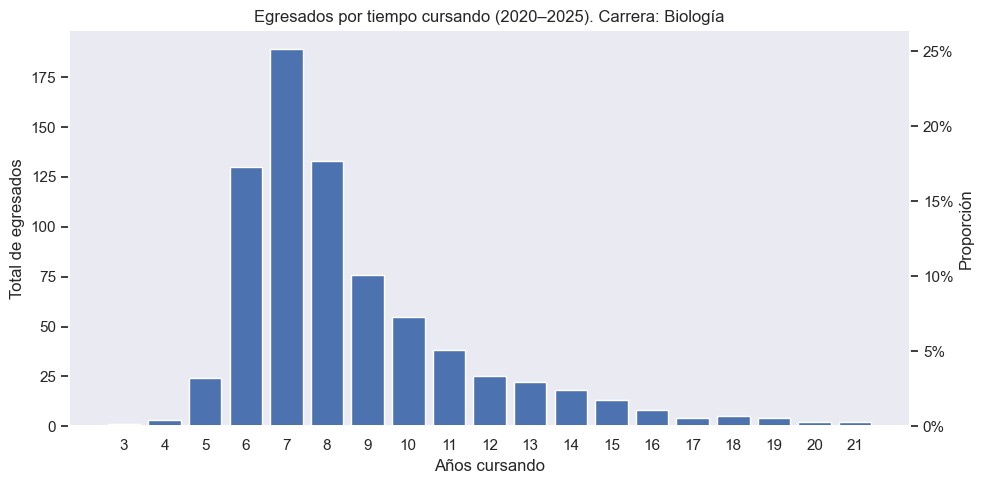

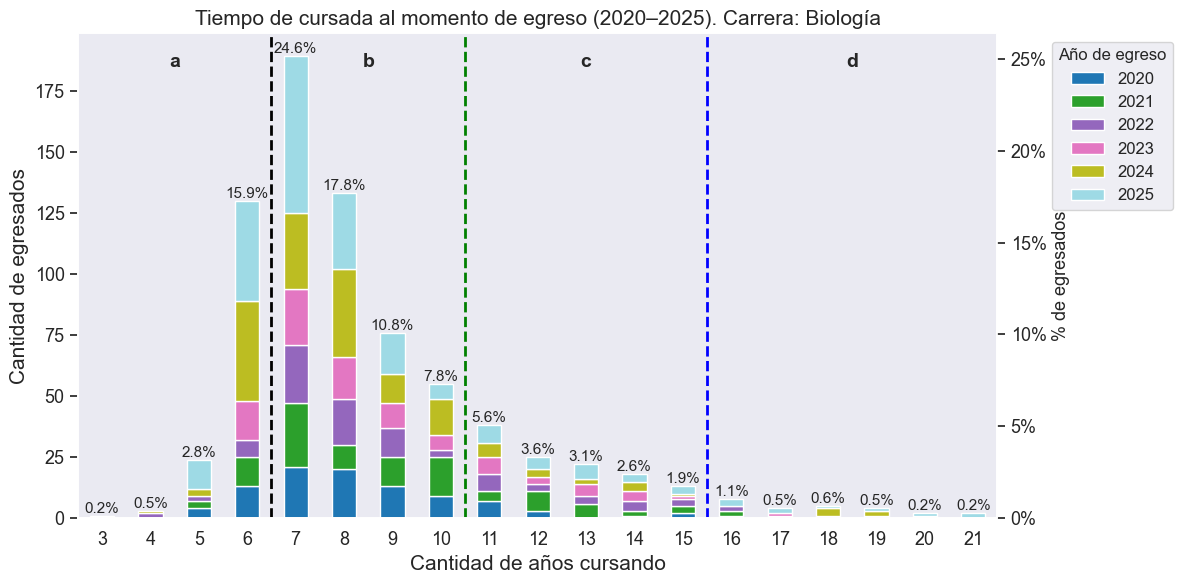

 tiempo_cursando  total_egreso
               3             1
               4             3
               5            24
               6           130
               7           189
               8           133
               9            76
              10            55
              11            38
              12            25
              13            22
              14            18
              15            13
              16             8
              17             4
              18             5
              19             4
              20             2
              21             2
anio_egreso      2020  2021  2022  2023  2024  2025
tiempo_cursando                                    
3                   0     0     1     0     0     0
4                   0     0     2     0     1     0
5                   4     3     2     0     3    12
6                  13    12     7    16    41    41
7                  21    26    24    23    31    64
8               

In [ ]:
total_por_tiempo_2020_2025_biologia, resumen_por_cohorte_2020_2025_biologia, promedio_ponderado_biologia = plot_tiempo_cursando(egresados_biologia_2020_2025, 'Biología', anio_desde=2020, anio_hasta=2025, mostrar_rectas_verticales=True)

In [11]:
resumen_por_cohorte_2020_2025_biologia

anio_egreso,2020,2021,2022,2023,2024,2025
tiempo_cursando,,,,,,
3,0,0,1,0,0,0
4,0,0,2,0,1,0
5,4,3,2,0,3,12
6,13,12,7,16,41,41
7,21,26,24,23,31,64
8,20,10,19,17,36,31
9,13,12,12,10,12,17
10,9,16,3,6,15,6
11,7,4,7,7,6,7


In [12]:
resumen_por_cohorte_2020_2025_biologia.sum()

anio_egreso
2020     94
2021    104
2022     93
2023     95
2024    161
2025    205
dtype: int64

Calculo a, b, c y "d" usando las proporciones reales, no las ponderadas.

In [60]:
# sumo tiempo cursando de 4 a 6 y lo divido por el total de egresados para obtener la proporción de egresados que se demoraron entre 4 y 6 años en finalizar la carrera
a = total_por_tiempo_2020_2025_biologia[total_por_tiempo_2020_2025_biologia['tiempo_cursando'] <= 6]['total_egreso'].sum() / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()
b = total_por_tiempo_2020_2025_biologia[(total_por_tiempo_2020_2025_biologia['tiempo_cursando'] > 6) & (total_por_tiempo_2020_2025_biologia['tiempo_cursando'] <= 10)]['total_egreso'].sum() / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()
c = total_por_tiempo_2020_2025_biologia[(total_por_tiempo_2020_2025_biologia['tiempo_cursando'] > 10) & (total_por_tiempo_2020_2025_biologia['tiempo_cursando'] <= 15)]['total_egreso'].sum() / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()
d = total_por_tiempo_2020_2025_biologia[total_por_tiempo_2020_2025_biologia['tiempo_cursando'] > 15]['total_egreso'].sum() / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()

In [61]:
print(f"a =", a)
print(f"b =", b)
print(f"c =", c)
print(f"d =", d)

a = 0.21010638297872342
b = 0.6023936170212766
c = 0.15425531914893617
d = 0.03324468085106383


In [13]:
# Proporción por año con tiempo_cursando entre 11 y 15 (inclusive)
mask_11_15_biologia = resumen_por_cohorte_2020_2025_biologia.index.to_series().between(11, 15)
proporcion_11_15_por_anio_biologia = (
    resumen_por_cohorte_2020_2025_biologia.loc[mask_11_15_biologia].sum()
    / resumen_por_cohorte_2020_2025_biologia.sum()
)
proporcion_11_15_por_anio_biologia = proporcion_11_15_por_anio_biologia.rename('proporcion_11_15')

proporcion_11_15_por_anio_biologia

anio_egreso
2020    0.138298
2021    0.221154
2022    0.215054
2023    0.210526
2024    0.099379
2025    0.117073
Name: proporcion_11_15, dtype: float64

In [14]:
desvio_estandar_biologia = (proporcion_11_15_por_anio_biologia * (1 - proporcion_11_15_por_anio_biologia) / resumen_por_cohorte_2020_2025_biologia.sum()) ** 0.5
desvio_estandar_biologia

anio_egreso
2020    0.035606
2021    0.040696
2022    0.042604
2023    0.041827
2024    0.023578
2025    0.022455
dtype: float64

In [15]:
limite_inferior = proporcion_11_15_por_anio_biologia - 1.96 * desvio_estandar_biologia
limite_superior = proporcion_11_15_por_anio_biologia + 1.96 * desvio_estandar_biologia

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
for anio in proporcion_11_15_por_anio_biologia.index:
    print(f"Año de egreso {anio}: [{limite_inferior[anio]:.4f}, {limite_superior[anio]:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020: [0.0685, 0.2081]
Año de egreso 2021: [0.1414, 0.3009]
Año de egreso 2022: [0.1315, 0.2986]
Año de egreso 2023: [0.1285, 0.2925]
Año de egreso 2024: [0.0532, 0.1456]
Año de egreso 2025: [0.0731, 0.1611]


## Computacion

In [16]:
egresados_computacion_2020_2025 = pd.DataFrame()
for anio in range(2020, 2026):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/computacion/resumen_egresados_computacion_{anio}.csv')
    egresados_computacion_2020_2025 = pd.concat([egresados_computacion_2020_2025, egresados])

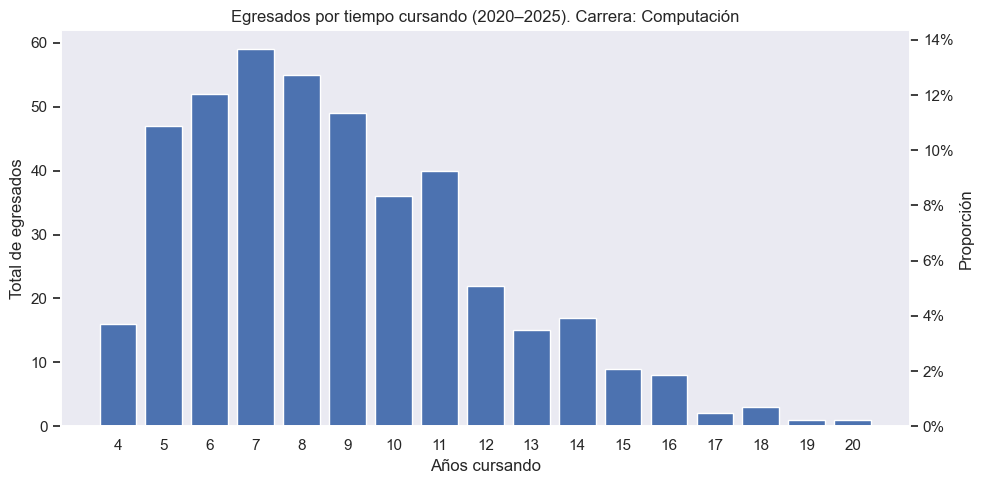

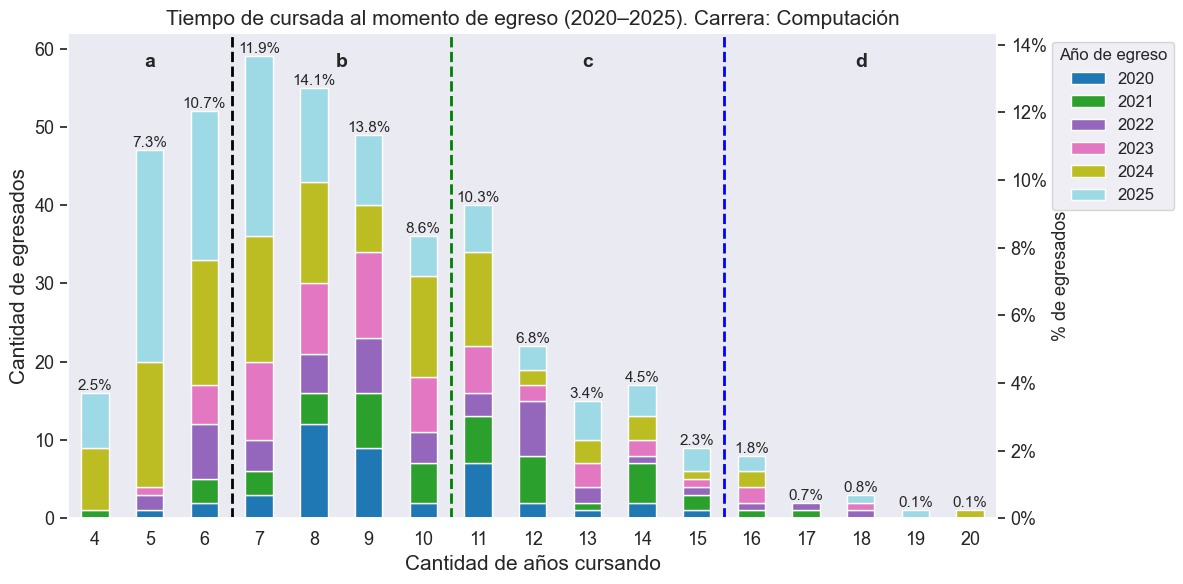

 tiempo_cursando  total_egreso
               4            16
               5            47
               6            52
               7            59
               8            55
               9            49
              10            36
              11            40
              12            22
              13            15
              14            17
              15             9
              16             8
              17             2
              18             3
              19             1
              20             1
anio_egreso      2020  2021  2022  2023  2024  2025
tiempo_cursando                                    
4                   0     1     0     0     8     7
5                   1     0     2     1    16    27
6                   2     3     7     5    16    19
7                   3     3     4    10    16    23
8                  12     4     5     9    13    12
9                   9     7     7    11     6     9
10                  2     

In [17]:
total_por_tiempo_2020_2025_computacion, resumen_por_cohorte_2020_2025_computacion, promedio_ponderado_computacion = plot_tiempo_cursando(egresados_computacion_2020_2025, 'Computación', anio_desde=2020, anio_hasta=2025, mostrar_rectas_verticales=True)

In [18]:
resumen_por_cohorte_2020_2025_computacion

anio_egreso,2020,2021,2022,2023,2024,2025
tiempo_cursando,,,,,,
4,0,1,0,0,8,7
5,1,0,2,1,16,27
6,2,3,7,5,16,19
7,3,3,4,10,16,23
8,12,4,5,9,13,12
9,9,7,7,11,6,9
10,2,5,4,7,13,5
11,7,6,3,6,12,6
12,2,6,7,2,2,3


In [19]:
resumen_por_cohorte_2020_2025_computacion.sum()

anio_egreso
2020     42
2021     45
2022     46
2023     60
2024    112
2025    127
dtype: int64

Calculo a, b, c y "d" usando las proporciones reales, no las ponderadas.

In [62]:
# sumo tiempo cursando de 4 a 6 y lo divido por el total de egresados para obtener la proporción de egresados que se demoraron entre 4 y 6 años en finalizar la carrera
a = total_por_tiempo_2020_2025_computacion[total_por_tiempo_2020_2025_computacion['tiempo_cursando'] <= 6]['total_egreso'].sum() / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()
b = total_por_tiempo_2020_2025_computacion[(total_por_tiempo_2020_2025_computacion['tiempo_cursando'] > 6) & (total_por_tiempo_2020_2025_computacion['tiempo_cursando'] <= 10)]['total_egreso'].sum() / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()
c = total_por_tiempo_2020_2025_computacion[(total_por_tiempo_2020_2025_computacion['tiempo_cursando'] > 10) & (total_por_tiempo_2020_2025_computacion['tiempo_cursando'] <= 15)]['total_egreso'].sum() / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()
d = total_por_tiempo_2020_2025_computacion[total_por_tiempo_2020_2025_computacion['tiempo_cursando'] > 15]['total_egreso'].sum() / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()

In [63]:
print(f"a=", a)
print(f"b=", b)
print(f"c=", c)
print(f"d=", d)

a= 0.2662037037037037
b= 0.46064814814814814
c= 0.23842592592592593
d= 0.034722222222222224


In [20]:
# Proporción por año con tiempo_cursando entre 11 y 15 (inclusive)
mask_11_15_computacion = resumen_por_cohorte_2020_2025_computacion.index.to_series().between(11, 15)
proporcion_11_15_por_anio_computacion = (
    resumen_por_cohorte_2020_2025_computacion.loc[mask_11_15_computacion].sum()
    / resumen_por_cohorte_2020_2025_computacion.sum()
)
proporcion_11_15_por_anio_computacion = proporcion_11_15_por_anio_computacion.rename('proporcion_11_15')

proporcion_11_15_por_anio_computacion

anio_egreso
2020    0.309524
2021    0.444444
2022    0.304348
2023    0.233333
2024    0.187500
2025    0.165354
Name: proporcion_11_15, dtype: float64

In [21]:
desvio_estandar_computacion = (proporcion_11_15_por_anio_computacion * (1 - proporcion_11_15_por_anio_computacion) / resumen_por_cohorte_2020_2025_computacion.sum()) ** 0.5
desvio_estandar_computacion

anio_egreso
2020    0.071334
2021    0.074074
2022    0.067843
2023    0.054603
2024    0.036881
2025    0.032965
dtype: float64

In [22]:
limite_inferior = proporcion_11_15_por_anio_computacion - 1.96 * desvio_estandar_computacion
limite_superior = proporcion_11_15_por_anio_computacion + 1.96 * desvio_estandar_computacion

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
for anio in proporcion_11_15_por_anio_computacion.index:
    print(f"Año de egreso {anio}: [{limite_inferior[anio]:.4f}, {limite_superior[anio]:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020: [0.1697, 0.4493]
Año de egreso 2021: [0.2993, 0.5896]
Año de egreso 2022: [0.1714, 0.4373]
Año de egreso 2023: [0.1263, 0.3404]
Año de egreso 2024: [0.1152, 0.2598]
Año de egreso 2025: [0.1007, 0.2300]


# Agrupando los años

## Fisica

In [23]:
# Proporción por año con tiempo_cursando entre 11 y 15 (inclusive)
proporcion_agrupado_11_15_por_anio = (
    total_por_tiempo_2020_2025[(total_por_tiempo_2020_2025['tiempo_cursando'] >= 11) & (total_por_tiempo_2020_2025['tiempo_cursando'] <= 15)]['total_egreso'].sum()
    / total_por_tiempo_2020_2025['total_egreso'].sum()
)

proporcion_agrupado_11_15_por_anio

np.float64(0.09943181818181818)

In [24]:
desvio_estandar_agrupado = (proporcion_agrupado_11_15_por_anio * (1 - proporcion_agrupado_11_15_por_anio) / total_por_tiempo_2020_2025['total_egreso'].sum()) ** 0.5
desvio_estandar_agrupado

np.float64(0.01594959493954136)

In [ ]:
limite_inferior = proporcion_agrupado_11_15_por_anio - 1.96 * desvio_estandar_agrupado
limite_superior = proporcion_agrupado_11_15_por_anio + 1.96 * desvio_estandar_agrupado

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
print(f"Año de egreso 2020-2025: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020-2025: [0.0682, 0.1307]


## Biología

In [26]:
# Proporción por año con tiempo_cursando entre 11 y 15 (inclusive)
proporcion_agrupado_11_15_por_anio_biologia = (
    total_por_tiempo_2020_2025_biologia[(total_por_tiempo_2020_2025_biologia['tiempo_cursando'] >= 11) & (total_por_tiempo_2020_2025_biologia['tiempo_cursando'] <= 15)]['total_egreso'].sum()
    / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()
)

proporcion_agrupado_11_15_por_anio_biologia

np.float64(0.15425531914893617)

In [27]:
desvio_estandar_biologia_agrupado = (proporcion_agrupado_11_15_por_anio_biologia * (1 - proporcion_agrupado_11_15_por_anio_biologia) / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()) ** 0.5
desvio_estandar_biologia_agrupado

np.float64(0.013171365200853326)

In [28]:
limite_inferior = proporcion_agrupado_11_15_por_anio_biologia - 1.96 * desvio_estandar_biologia_agrupado
limite_superior = proporcion_agrupado_11_15_por_anio_biologia + 1.96 * desvio_estandar_biologia_agrupado

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
print(f"Año de egreso 2020-2025: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020-2025: [0.1284, 0.1801]


## Computacion

In [29]:
# Proporción por año con tiempo_cursando entre 11 y 15 (inclusive)
proporcion_agrupado_11_15_por_anio_computacion = (
    total_por_tiempo_2020_2025_computacion[(total_por_tiempo_2020_2025_computacion['tiempo_cursando'] >= 11) & (total_por_tiempo_2020_2025_computacion['tiempo_cursando'] <= 15)]['total_egreso'].sum()
    / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()
)

proporcion_agrupado_11_15_por_anio_computacion

np.float64(0.23842592592592593)

In [30]:
desvio_estandar_computacion_agrupado = (proporcion_agrupado_11_15_por_anio_computacion * (1 - proporcion_agrupado_11_15_por_anio_computacion) / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()) ** 0.5
desvio_estandar_computacion_agrupado

np.float64(0.020501750364088765)

In [31]:
limite_inferior = proporcion_agrupado_11_15_por_anio_computacion - 1.96 * desvio_estandar_computacion_agrupado
limite_superior = proporcion_agrupado_11_15_por_anio_computacion + 1.96 * desvio_estandar_computacion_agrupado

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
print(f"Año de egreso 2020-2025: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020-2025: [0.1982, 0.2786]


# Buscando ese 2%

La idea es relativamente simple, para cada año vemos cuantos años (yendo en orden de 20 a menos) necesitamos para conseguir un 3% de los egresados y ahí calculamos el intervalo de confianza

In [32]:
import numpy as np

def calcular_umbral_desde_20_con_ic(
    resumen_por_cohorte,
    umbral=0.03,
    z=1.96,
    tiempo_max=20,
    clamp_ic=True,
    incluir_detalle=False
    ):
    """
    Para cada año (columna), acumula desde tiempo_max hacia abajo hasta alcanzar `umbral`
    y calcula el IC del 95% (o el z que se indique) para la proporción lograda.

    Nota importante:
    - El denominador (n_total) es SIEMPRE el total de casos registrados del año.
    - tiempo_max solo afecta qué tiempos entran en el acumulado del numerador.

    Parametros
    ----------
    resumen_por_cohorte : pd.DataFrame
        Filas: tiempo_cursando. Columnas: año de egreso.
    umbral : float
        Proporción objetivo mínima a alcanzar (ej. 0.03).
    z : float
        Valor z para el IC (1.96 para 95%).
    tiempo_max : int
        Tiempo de cursado desde el cual empezar a acumular hacia abajo.
    clamp_ic : bool
        Si True, recorta el IC al rango [0, 1].
    incluir_detalle : bool
        Si True, incluye la serie acumulada por año en un diccionario.

    Retorna
    -------
    pd.DataFrame o (pd.DataFrame, dict)
    """

    resumen_base = resumen_por_cohorte.copy()
    resumen_base.index = pd.to_numeric(resumen_base.index, errors='coerce')
    resumen_base = resumen_base[resumen_base.index.notna()].sort_index(ascending=False)

    resumen_acotado = resumen_base[resumen_base.index <= tiempo_max]

    filas_resultado = []
    detalle = {}

    for anio in resumen_base.columns:
        serie_total_anio = resumen_base[anio].fillna(0)
        n_total = serie_total_anio.sum()

        if n_total == 0:
            filas_resultado.append({
                'anio_egreso': anio,
                'anios_necesarios_desde_max': np.nan,
                'tiempo_minimo_incluido': np.nan,
                'proporcion_lograda': np.nan,
                'ic_inf': np.nan,
                'ic_sup': np.nan
            })
            continue

        serie_anio_acotada = resumen_acotado[anio].fillna(0)
        proporcion_acum = serie_anio_acotada.cumsum() / n_total

        if incluir_detalle:
            detalle[anio] = proporcion_acum

        candidatos = proporcion_acum[proporcion_acum >= umbral]

        if len(candidatos) > 0:
            tiempo_min = candidatos.index[0]
            proporcion_objetivo = candidatos.iloc[0]
            anios_necesarios = int(tiempo_max - tiempo_min + 1)
        else:
            tiempo_min = np.nan
            proporcion_objetivo = proporcion_acum.iloc[-1] if len(proporcion_acum) > 0 else 0.0
            anios_necesarios = np.nan

        desvio = np.sqrt(proporcion_objetivo * (1 - proporcion_objetivo) / n_total)
        ic_inf = proporcion_objetivo - z * desvio
        ic_sup = proporcion_objetivo + z * desvio

        if clamp_ic:
            ic_inf = max(0.0, ic_inf)
            ic_sup = min(1.0, ic_sup)

        filas_resultado.append({
            'anio_egreso': anio,
            'anios_necesarios_desde_max': anios_necesarios,
            'tiempo_minimo_incluido': tiempo_min,
            'proporcion_lograda': proporcion_objetivo,
            'ic_inf': ic_inf,
            'ic_sup': ic_sup
        })

    resultado = pd.DataFrame(filas_resultado).set_index('anio_egreso')
    resultado.index.name = 'anio_egreso'

    if incluir_detalle:
        return resultado, detalle
    return resultado

In [33]:
# Uso con cada carrera
resultado_3pct_fisica = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025, tiempo_max=20, umbral=0.03)
resultado_3pct_biologia = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025_biologia, tiempo_max=21, umbral=0.03)
resultado_3pct_computacion = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025_computacion, tiempo_max=20, umbral=0.03)

In [34]:
resultado_3pct_fisica

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,5,16,0.044444,0.000000,0.104657
2021,9,12,0.049180,0.000000,0.103447
2022,7,14,0.055556,0.000000,0.116651
2023,9,12,0.093023,0.006204,0.179842
2024,2,19,0.033898,0.000000,0.080076
2025,7,14,0.044444,0.001868,0.087021


In [35]:
resultado_3pct_biologia

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,7,15,0.031915,0.000000,0.067449
2021,7,15,0.048077,0.006961,0.089193
2022,6,16,0.032258,0.000000,0.068168
2023,5,17,0.031579,0.000000,0.066745
2024,4,18,0.037267,0.008008,0.066526
2025,5,17,0.034146,0.009286,0.059007


In [36]:
resultado_3pct_computacion

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,7,14,0.071429,0.000000,0.149317
2021,5,16,0.044444,0.000000,0.104657
2022,4,17,0.043478,0.000000,0.102412
2023,5,16,0.050000,0.000000,0.105148
2024,6,15,0.035714,0.001345,0.070084
2025,5,16,0.031496,0.001120,0.061872


In [37]:
# Uso con cada carrera
resultado_3pct_fisica = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025, tiempo_max=20, umbral=0.02)
resultado_3pct_biologia = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025_biologia, tiempo_max=21, umbral=0.02)
resultado_3pct_computacion = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025_computacion, tiempo_max=20, umbral=0.02)

In [38]:
resultado_3pct_fisica

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,5,16,0.044444,0.0,0.104657
2021,9,12,0.049180,0.0,0.103447
2022,7,14,0.055556,0.0,0.116651
2023,4,17,0.023256,0.0,0.068304
2024,2,19,0.033898,0.0,0.080076
2025,6,15,0.022222,0.0,0.052677


In [39]:
resultado_3pct_biologia

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,7,15,0.031915,0.000000,0.067449
2021,7,15,0.048077,0.006961,0.089193
2022,6,16,0.032258,0.000000,0.068168
2023,4,18,0.021053,0.000000,0.049921
2024,4,18,0.037267,0.008008,0.066526
2025,4,18,0.024390,0.003274,0.045507


In [40]:
resultado_3pct_computacion

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,6,15,0.023810,0.00000,0.069917
2021,4,17,0.022222,0.00000,0.065291
2022,3,18,0.021739,0.00000,0.063882
2023,5,16,0.050000,0.00000,0.105148
2024,5,16,0.026786,0.00000,0.056688
2025,5,16,0.031496,0.00112,0.061872


In [41]:
# Uso con cada carrera
resultado_3pct_fisica = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025, tiempo_max=15, umbral=0.02)
resultado_3pct_biologia = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025_biologia, tiempo_max=15, umbral=0.02)
resultado_3pct_computacion = calcular_umbral_desde_20_con_ic(resumen_por_cohorte_2020_2025_computacion, tiempo_max=15, umbral=0.02)

In [42]:
resultado_3pct_fisica

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,2,14,0.022222,0.0,0.065291
2021,4,12,0.032787,0.0,0.077476
2022,2,14,0.055556,0.0,0.116651
2023,4,12,0.069767,0.0,0.145913
2024,3,13,0.033898,0.0,0.080076
2025,2,14,0.033333,0.0,0.070420


In [43]:
resultado_3pct_biologia

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,1,15,0.021277,0.000000,0.050449
2021,1,15,0.028846,0.000000,0.061014
2022,1,15,0.032258,0.000000,0.068168
2023,2,14,0.052632,0.007728,0.097535
2024,2,14,0.031056,0.004260,0.057852
2025,2,14,0.029268,0.006194,0.052343


In [44]:
resultado_3pct_computacion

,anios_necesarios_desde_max,tiempo_minimo_incluido,proporcion_lograda,ic_inf,ic_sup
anio_egreso,,,,,
2020,1,15,0.023810,0.000000,0.069917
2021,1,15,0.044444,0.000000,0.104657
2022,1,15,0.021739,0.000000,0.063882
2023,2,14,0.050000,0.000000,0.105148
2024,2,14,0.035714,0.001345,0.070084
2025,1,15,0.023622,0.000000,0.050035


In [45]:
for anio in resumen_por_cohorte_2020_2025.columns:
    print(f"Año de egreso {anio}:")
    resumen_copy = resumen_por_cohorte_2020_2025.copy()
    resumen_copy = resumen_copy.sort_index(ascending=False)
    serie_anio =resumen_copy[anio]
    proporcion_acum = serie_anio.cumsum() / serie_anio.sum()
    print(proporcion_acum)

Año de egreso 2020:
tiempo_cursando
20    0.000000
19    0.000000
17    0.000000
16    0.044444
15    0.044444
14    0.066667
13    0.111111
12    0.177778
11    0.177778
10    0.200000
9     0.311111
8     0.488889
7     0.733333
6     0.955556
5     1.000000
4     1.000000
Name: 2020, dtype: float64
Año de egreso 2021:
tiempo_cursando
20    0.000000
19    0.000000
17    0.000000
16    0.016393
15    0.016393
14    0.016393
13    0.016393
12    0.049180
11    0.114754
10    0.163934
9     0.262295
8     0.360656
7     0.721311
6     1.000000
5     1.000000
4     1.000000
Name: 2021, dtype: float64
Año de egreso 2022:
tiempo_cursando
20    0.000000
19    0.000000
17    0.000000
16    0.000000
15    0.000000
14    0.055556
13    0.055556
12    0.111111
11    0.129630
10    0.240741
9     0.388889
8     0.518519
7     0.759259
6     1.000000
5     1.000000
4     1.000000
Name: 2022, dtype: float64
Año de egreso 2023:
tiempo_cursando
20    0.000000
19    0.000000
17    0.023256
16    0.02

In [46]:
for anio in resumen_por_cohorte_2020_2025_biologia.columns:
    print(f"Año de egreso {anio}:")
    resumen_copy = resumen_por_cohorte_2020_2025_biologia.copy()
    resumen_copy = resumen_copy.sort_index(ascending=False)
    serie_anio =resumen_copy[anio]
    proporcion_acum = serie_anio.cumsum() / serie_anio.sum()
    print(proporcion_acum)

Año de egreso 2020:
tiempo_cursando
21    0.000000
20    0.000000
19    0.000000
18    0.000000
17    0.000000
16    0.010638
15    0.031915
14    0.042553
13    0.042553
12    0.074468
11    0.148936
10    0.244681
9     0.382979
8     0.595745
7     0.819149
6     0.957447
5     1.000000
4     1.000000
3     1.000000
Name: 2020, dtype: float64
Año de egreso 2021:
tiempo_cursando
21    0.000000
20    0.000000
19    0.000000
18    0.000000
17    0.000000
16    0.019231
15    0.048077
14    0.067308
13    0.125000
12    0.201923
11    0.240385
10    0.394231
9     0.509615
8     0.605769
7     0.855769
6     0.971154
5     1.000000
4     1.000000
3     1.000000
Name: 2021, dtype: float64
Año de egreso 2022:
tiempo_cursando
21    0.000000
20    0.000000
19    0.000000
18    0.000000
17    0.010753
16    0.032258
15    0.064516
14    0.107527
13    0.139785
12    0.172043
11    0.247312
10    0.279570
9     0.408602
8     0.612903
7     0.870968
6     0.946237
5     0.967742
4     0.98924

In [47]:
for anio in resumen_por_cohorte_2020_2025_computacion.columns:
    print(f"Año de egreso {anio}:")
    resumen_copy = resumen_por_cohorte_2020_2025_computacion.copy()
    resumen_copy = resumen_copy.sort_index(ascending=False)
    serie_anio =resumen_copy[anio]
    proporcion_acum = serie_anio.cumsum() / serie_anio.sum()
    print(proporcion_acum)

Año de egreso 2020:
tiempo_cursando
20    0.000000
19    0.000000
18    0.000000
17    0.000000
16    0.000000
15    0.023810
14    0.071429
13    0.095238
12    0.142857
11    0.309524
10    0.357143
9     0.571429
8     0.857143
7     0.928571
6     0.976190
5     1.000000
4     1.000000
Name: 2020, dtype: float64
Año de egreso 2021:
tiempo_cursando
20    0.000000
19    0.000000
18    0.000000
17    0.022222
16    0.044444
15    0.088889
14    0.200000
13    0.222222
12    0.355556
11    0.488889
10    0.600000
9     0.755556
8     0.844444
7     0.911111
6     0.977778
5     0.977778
4     1.000000
Name: 2021, dtype: float64
Año de egreso 2022:
tiempo_cursando
20    0.000000
19    0.000000
18    0.021739
17    0.043478
16    0.065217
15    0.086957
14    0.108696
13    0.152174
12    0.304348
11    0.369565
10    0.456522
9     0.608696
8     0.717391
7     0.804348
6     0.956522
5     1.000000
4     1.000000
Name: 2022, dtype: float64
Año de egreso 2023:
tiempo_cursando
20    0.00

## Calculo d

In [48]:
total_por_tiempo_2020_2025

,tiempo_cursando,total_egreso
0,4,1
1,5,24
2,6,88
3,7,94
4,8,49
5,9,38
6,10,16
7,11,12
8,12,12
9,13,3


In [49]:
total_por_tiempo_2020_2025_copy = total_por_tiempo_2020_2025.copy()
total_por_tiempo_2020_2025_copy = total_por_tiempo_2020_2025_copy.sort_values(by='tiempo_cursando', ascending=False)
total_por_tiempo_2020_2025_copy['proporcion_acum'] = total_por_tiempo_2020_2025_copy['total_egreso'].cumsum() / total_por_tiempo_2020_2025_copy['total_egreso'].sum()
print(total_por_tiempo_2020_2025_copy)

    tiempo_cursando  total_egreso  proporcion_acum
15               20             1         0.002841
14               19             2         0.008523
13               17             1         0.011364
12               16             3         0.019886
11               15             1         0.022727
10               14             7         0.042614
9                13             3         0.051136
8                12            12         0.085227
7                11            12         0.119318
6                10            16         0.164773
5                 9            38         0.272727
4                 8            49         0.411932
3                 7            94         0.678977
2                 6            88         0.928977
1                 5            24         0.997159
0                 4             1         1.000000


In [50]:
total_por_tiempo_2020_2025_copy = total_por_tiempo_2020_2025_biologia.copy()
total_por_tiempo_2020_2025_copy = total_por_tiempo_2020_2025_copy.sort_values(by='tiempo_cursando', ascending=False)
total_por_tiempo_2020_2025_copy['proporcion_acum'] = total_por_tiempo_2020_2025_copy['total_egreso'].cumsum() / total_por_tiempo_2020_2025_copy['total_egreso'].sum()
print(total_por_tiempo_2020_2025_copy)

    tiempo_cursando  total_egreso  proporcion_acum
18               21             2         0.002660
17               20             2         0.005319
16               19             4         0.010638
15               18             5         0.017287
14               17             4         0.022606
13               16             8         0.033245
12               15            13         0.050532
11               14            18         0.074468
10               13            22         0.103723
9                12            25         0.136968
8                11            38         0.187500
7                10            55         0.260638
6                 9            76         0.361702
5                 8           133         0.538564
4                 7           189         0.789894
3                 6           130         0.962766
2                 5            24         0.994681
1                 4             3         0.998670
0                 3            

In [51]:
total_por_tiempo_2020_2025_copy = total_por_tiempo_2020_2025_computacion.copy()
total_por_tiempo_2020_2025_copy = total_por_tiempo_2020_2025_copy.sort_values(by='tiempo_cursando', ascending=False)
total_por_tiempo_2020_2025_copy['proporcion_acum'] = total_por_tiempo_2020_2025_copy['total_egreso'].cumsum() / total_por_tiempo_2020_2025_copy['total_egreso'].sum()
print(total_por_tiempo_2020_2025_copy)

    tiempo_cursando  total_egreso  proporcion_acum
16               20             1         0.002315
15               19             1         0.004630
14               18             3         0.011574
13               17             2         0.016204
12               16             8         0.034722
11               15             9         0.055556
10               14            17         0.094907
9                13            15         0.129630
8                12            22         0.180556
7                11            40         0.273148
6                10            36         0.356481
5                 9            49         0.469907
4                 8            55         0.597222
3                 7            59         0.733796
2                 6            52         0.854167
1                 5            47         0.962963
0                 4            16         1.000000


# Trabajamos con los ponderados

## Fisica

In [85]:
promedio_ponderado

tiempo_cursando
4     0.003876
5     0.052040
6     0.242156
7     0.272795
8     0.139331
9     0.111720
10    0.050600
11    0.035075
12    0.039315
13    0.010232
14    0.019492
15    0.001852
16    0.010140
17    0.003876
19    0.005650
20    0.001852
Name: proporcion, dtype: float64

In [86]:
# sumo tiempo cursando de 4 a 6 y lo divido por el total de egresados para obtener la proporción de egresados que se demoraron entre 4 y 6 años en finalizar la carrera
a_ponderado = promedio_ponderado[0:3].sum()
b_ponderado = promedio_ponderado[3:7].sum()
c_ponderado = promedio_ponderado[7:12].sum()
d_ponderado = promedio_ponderado[12:16].sum()

In [87]:
print(f"a_ponderado =", a_ponderado)
print(f"b_ponderado =", b_ponderado)
print(f"c_ponderado =", c_ponderado)
print(f"d_ponderado =", d_ponderado)

a_ponderado = 0.29807244204514327
b_ponderado = 0.5744453052124647
c_ponderado = 0.10596506653960155
d_ponderado = 0.02151718620279005


Calculamos el p pero con los ponderados

In [88]:
desvio_estandar_agrupado = (c_ponderado * (1 - c_ponderado) / total_por_tiempo_2020_2025['total_egreso'].sum()) ** 0.5
desvio_estandar_agrupado

limite_inferior = c_ponderado - 1.96 * desvio_estandar_agrupado
limite_superior = c_ponderado + 1.96 * desvio_estandar_agrupado

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
print(f"Año de egreso 2020-2025: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020-2025: [0.0738, 0.1381]


## Biología

In [89]:
promedio_ponderado_biologia

tiempo_cursando
3     0.001792
4     0.004619
5     0.028346
6     0.158672
7     0.246386
8     0.177832
9     0.107573
10    0.077907
11    0.055549
12    0.035950
13    0.030712
14    0.025744
15    0.018959
16    0.011001
17    0.005173
18    0.005673
19    0.004638
20    0.001848
21    0.001626
Name: proporcion, dtype: float64

In [90]:
# sumo tiempo cursando de 4 a 6 y lo divido por el total de egresados para obtener la proporción de egresados que se demoraron entre 4 y 6 años en finalizar la carrera
a_ponderado = promedio_ponderado_biologia[0:3].sum()
b_ponderado = promedio_ponderado_biologia[3:7].sum()
c_ponderado = promedio_ponderado_biologia[7:12].sum()
d_ponderado = promedio_ponderado_biologia[12:16].sum()

In [91]:
print(f"a_ponderado =", a_ponderado)
print(f"b_ponderado =", b_ponderado)
print(f"c_ponderado =", c_ponderado)
print(f"d_ponderado =", d_ponderado)

a_ponderado = 0.03475734867641308
b_ponderado = 0.6904626035772135
c_ponderado = 0.22586236376303914
d_ponderado = 0.0408056754359846


In [95]:
desvio_estandar_agrupado = (c_ponderado * (1 - c_ponderado) / total_por_tiempo_2020_2025_biologia['total_egreso'].sum()) ** 0.5
desvio_estandar_agrupado

limite_inferior = c_ponderado - 1.96 * desvio_estandar_agrupado
limite_superior = c_ponderado + 1.96 * desvio_estandar_agrupado

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
print(f"Año de egreso 2020-2025: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020-2025: [0.2422, 0.3060]


## Computacion

In [92]:
promedio_ponderado_computacion

tiempo_cursando
4     0.024795
5     0.073235
6     0.107043
7     0.119280
8     0.140643
9     0.138298
10    0.086299
11    0.103267
12    0.067990
13    0.034278
14    0.045347
15    0.023202
16    0.018483
17    0.007327
18    0.007713
19    0.001312
20    0.001488
Name: proporcion, dtype: float64

In [93]:
# sumo tiempo cursando de 4 a 6 y lo divido por el total de egresados para obtener la proporción de egresados que se demoraron entre 4 y 6 años en finalizar la carrera
a_ponderado = promedio_ponderado_computacion[0:3].sum()
b_ponderado = promedio_ponderado_computacion[3:7].sum()
c_ponderado = promedio_ponderado_computacion[7:12].sum()
d_ponderado = promedio_ponderado_computacion[12:16].sum()

In [94]:
print(f"a_ponderado =", a_ponderado)
print(f"b_ponderado =", b_ponderado)
print(f"c_ponderado =", c_ponderado)
print(f"d_ponderado =", d_ponderado)

a_ponderado = 0.20507255433650495
b_ponderado = 0.48451955280952175
c_ponderado = 0.274083957349534
d_ponderado = 0.03483584026634343


In [96]:
desvio_estandar_agrupado = (c_ponderado * (1 - c_ponderado) / total_por_tiempo_2020_2025_computacion['total_egreso'].sum()) ** 0.5
desvio_estandar_agrupado

limite_inferior = c_ponderado - 1.96 * desvio_estandar_agrupado
limite_superior = c_ponderado + 1.96 * desvio_estandar_agrupado

print(f"Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: ")
print(f"Año de egreso 2020-2025: [{limite_inferior:.4f}, {limite_superior:.4f}]")

Intervalo de confianza del 95% para la proporción de egresados con tiempo_cursando entre 11 y 15 años: 
Año de egreso 2020-2025: [0.2320, 0.3161]
